Use breast cancer wisconsin dataset available directly in scikit-learn.
The task is to predict whether a tumour is: Malignant or Benign

In [2]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [3]:
#Load the dataset
data = load_breast_cancer()
x = pd.DataFrame(data.data, columns = data.feature_names)
y = pd.Series((data.target == 0).astype(int), name = "malignant")
print(y.value_counts())
print("feature matrix shape: ", x.shape)
print("target shape: ", y.shape)
print("class names: ", data.target_names)

malignant
0    357
1    212
Name: count, dtype: int64
feature matrix shape:  (569, 30)
target shape:  (569,)
class names:  ['malignant' 'benign']


In [4]:
#examine the class distribution
class_counts = y.value_counts().sort_index()
class_distribution = pd.DataFrame({
    "class": data.target_names,
    "count": class_counts.values,
    "probability": class_counts.values / len(y)
})
print(class_distribution)

       class  count  probability
0  malignant    357     0.627417
1     benign    212     0.372583


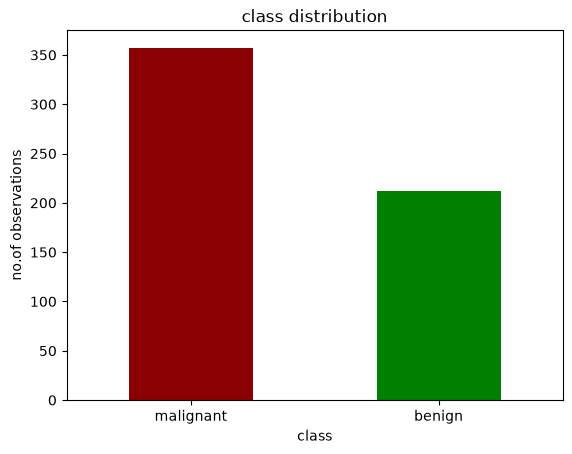

In [5]:
class_distribution.plot(
    x = "class",
    y = "count",
    kind = "bar",
    legend = False,
    color = ["darkred", "green"]
)
plt.ylabel("no.of observations")
plt.title("class distribution")
plt.xticks(rotation=0)
plt.show()

In [6]:
#create training and testing samples
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.20,
    random_state = 42,
    stratify = y
)
print("training size:", len(y_train))
print("testing size:", len(y_test))
print("\nTraining properties: ")
print(y_train.value_counts(normalize=True).sort_index())
print("\nTesting properties: ")
print(y_test.value_counts(normalize=True).sort_index())

training size: 455
testing size: 114

Training properties: 
malignant
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Testing properties: 
malignant
0    0.631579
1    0.368421
Name: proportion, dtype: float64


In [7]:
#Train a logistic regression model
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter = 1000)
)
model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['mean radius','mean texture','mean perimeter',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [8]:
#predicted probabilities
probabilities = model.predict_proba(x_test)
print(probabilities[:5])

[[9.99635432e-01 3.64568116e-04]
 [1.07465986e-08 9.99999989e-01]
 [9.57432053e-01 4.25679471e-02]
 [4.23812678e-01 5.76187322e-01]
 [4.90844511e-01 5.09155489e-01]]


In [9]:
results = pd.DataFrame({
    "Actual_class": y_test.values,
    "P_malignant": probabilities[:,0],
    "P_benign": probabilities[:,1]
})
print(results.head(10))

   Actual_class   P_malignant  P_benign
0             0  9.996354e-01  0.000365
1             1  1.074660e-08  1.000000
2             0  9.574321e-01  0.042568
3             1  4.238127e-01  0.576187
4             0  4.908445e-01  0.509155
5             0  9.993840e-01  0.000616
6             1  2.384659e-01  0.761534
7             0  9.989878e-01  0.001012
8             0  9.994313e-01  0.000569
9             0  9.892324e-01  0.010768


In [10]:
results["Actual_label"] = results["Actual_class"].map({
    0: "Malignant",
    1: "Benign"
})
print(
    results[
        ["Actual_label", "P_malignant", "P_benign"]
    ].head(10)
)

  Actual_label   P_malignant  P_benign
0    Malignant  9.996354e-01  0.000365
1       Benign  1.074660e-08  1.000000
2    Malignant  9.574321e-01  0.042568
3       Benign  4.238127e-01  0.576187
4    Malignant  4.908445e-01  0.509155
5    Malignant  9.993840e-01  0.000616
6       Benign  2.384659e-01  0.761534
7    Malignant  9.989878e-01  0.001012
8    Malignant  9.994313e-01  0.000569
9    Malignant  9.892324e-01  0.010768


In [11]:
#use a threshold to generate predictions
threshold = 0.50

results["Predicted_malignant"] = (
    results["P_malignant"] >= threshold
).astype(int)

results["Predicted_label"] = results[
    "Predicted_malignant"
].map({
    1: "Malignant",
    0: "Benign"
})

print(
    results[
        [
            "Actual_label",
            "P_malignant",
            "Predicted_label"
        ]
    ].head(10)
)

  Actual_label   P_malignant Predicted_label
0    Malignant  9.996354e-01       Malignant
1       Benign  1.074660e-08          Benign
2    Malignant  9.574321e-01       Malignant
3       Benign  4.238127e-01          Benign
4    Malignant  4.908445e-01          Benign
5    Malignant  9.993840e-01       Malignant
6       Benign  2.384659e-01          Benign
7    Malignant  9.989878e-01       Malignant
8    Malignant  9.994313e-01       Malignant
9    Malignant  9.892324e-01       Malignant


In [12]:
#compare different thresholds
for threshold in [0.30, 0.50, 0.70]:
    predictions = (
        results["P_malignant"] >= threshold
    ).astype(int)

    print(
        f"Threshold = {threshold}: "
        f"Predicted malignant cases = {predictions.sum()}"
    )

Threshold = 0.3: Predicted malignant cases = 76
Threshold = 0.5: Predicted malignant cases = 74
Threshold = 0.7: Predicted malignant cases = 72


In [13]:
#construct a confusion matrix
actual_malignant = (y_test.values == 0).astype(int)

for threshold in [0.30, 0.50, 0.70]:
    predicted_malignant = (
        probabilities[:, 0] >= threshold
    ).astype(int)

    cm = confusion_matrix(
        actual_malignant,
        predicted_malignant
    )

    print(f"\nThreshold = (threshold)")
    print(cm)


Threshold = (threshold)
[[38  4]
 [ 0 72]]

Threshold = (threshold)
[[39  3]
 [ 1 71]]

Threshold = (threshold)
[[41  1]
 [ 1 71]]


In [14]:
#verify using sklearn
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print(
    "sklearn accuracy:",
    accuracy_score(y_test, y_pred)
)
print(
    "sklearn precision:",
    precision_score(y_test, y_pred)
)
print(
    "sklearn recall:",
    recall_score(y_test, y_pred)
)
print(
    "sklearn f1 score:",
    f1_score(y_test, y_pred)
)

NameError: name 'y_pred' is not defined

In [19]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

y_probs = model.predict_proba(x_test)[:, 1]

thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
metrics_list = []

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
  
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    sensitivity_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0
    
    metrics_list.append({
        'Threshold': t,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp,
        'Accuracy': accuracy,
        'Precision': precision,
        'Sensitivity_Recall': sensitivity_recall,
        'F1_score': f1_score
    })

threshold_metrics = pd.DataFrame(metrics_list)
display(threshold_metrics.round(3))

,Threshold,TN,FP,FN,TP,Accuracy,Precision,Sensitivity_Recall,F1_score
0,0.1,67,5,1,41,0.947,0.891,0.976,0.932
1,0.3,71,1,1,41,0.982,0.976,0.976,0.976
2,0.5,71,1,3,39,0.965,0.975,0.929,0.951
3,0.7,72,0,4,38,0.965,1.000,0.905,0.950
4,0.9,72,0,9,33,0.921,1.000,0.786,0.880
